# importing and cleaning

# Importing

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import warnings
import yfinance as yf
warnings.filterwarnings('ignore')
%matplotlib inline

In [46]:
end = dt.date.today()
start = end - dt.timedelta(days=365*5)
df = yf.download('RELIANCE.NS', start, end,auto_adjust=True)
df.columns = df.columns.droplevel(1)
df.columns = df.columns.str.lower()
df = df.drop(columns=['high','low','open','volume'])
df.index = pd.to_datetime(df.index)

[*********************100%***********************]  1 of 1 completed


In [47]:
df1 = df.copy()

# Moving Average Crossover
Long only


Buy and Hold = 1.4820735748740246
strategy_returns = 1.1904235313857463


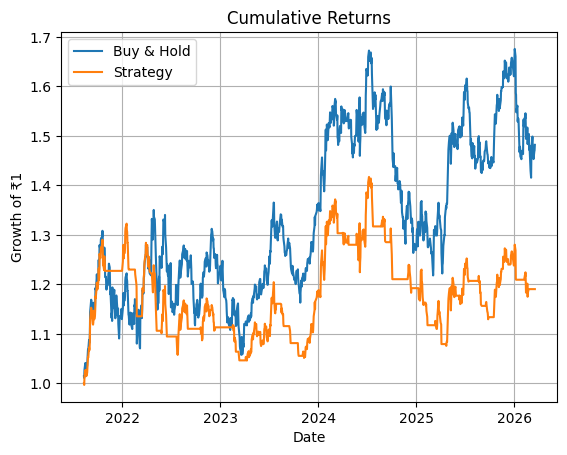

In [76]:
# Returns
df['returns'] = df['close'].pct_change()

# Moving Averages
s_ma = 5
l_ma = 20
df['ma_short'] = df['close'].rolling(s_ma).mean()
df['ma_long'] = df['close'].rolling(l_ma).mean()

# Trigger
df['signal'] = np.where(df['ma_short'] > df['ma_long'], 1, 0)
df['position'] = df['signal'].shift(1)
df = df.dropna()

# Returns
df['strategy_return'] = df['returns'] * df['position']
df['strategy_return'] = 1 + df['strategy_return']
df['buy_and_hold'] = 1 + df['returns']

# Comparison
print("Buy and Hold =",df['buy_and_hold'].cumprod().iloc[-1])

print("strategy_returns =",df['strategy_return'].cumprod().iloc[-1])

plt.plot(df['buy_and_hold'].cumprod(), label='Buy & Hold')
plt.plot(df['strategy_return'].cumprod(), label='Strategy')

plt.title('Cumulative Returns')
plt.xlabel('Date')
plt.ylabel('Growth of ₹1')
plt.legend()
plt.grid()

plt.show()

# Rsi Strategy
Long and Short

In [77]:
dfa = df1.copy()

RSI Strategy Returns =  1.0897671319751963
Buy Hold Returns =  1.3747399102520759


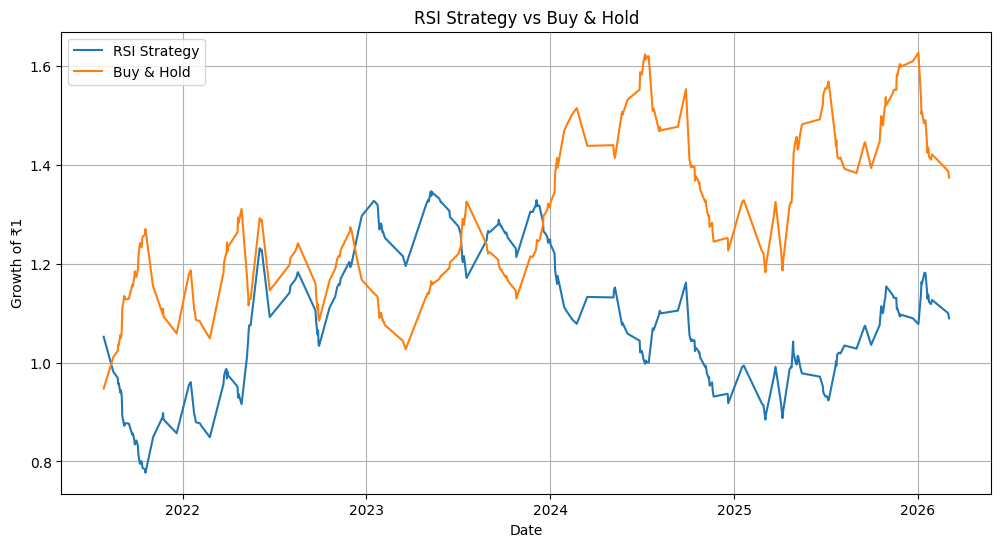

In [80]:
# Change
dfa['change'] = dfa['close'] - dfa['close'].shift(1)

# Gain and loss in change
dfa['gain'] = dfa['change'].apply(lambda x: x if x > 0 else 0)
dfa['loss'] = dfa['change'].apply(lambda x: x if x < 0 else 0)
dfa['loss'] = dfa['loss'] * -1

#average gain and loss
dfa['avg_gain'] = dfa['gain'].ewm(span=14, adjust=False).mean()
dfa['avg_loss'] = dfa['loss'].ewm(span=14, adjust=False).mean()
dfa.dropna(inplace=True)

# Calculating Rsi
dfa['rs'] = dfa['avg_gain'] / dfa['avg_loss']
dfa['rsi'] = 100 - (100 / (1 + dfa['rs']))


# Create signal
dfa['signal'] = np.where(dfa['rsi'] < 30, 1,
                  np.where(dfa['rsi'] > 70, -1, np.nan))

# Forward fill to maintain position
dfa['position'] = dfa['signal'].ffill()
dfa['position'] = dfa['position'].fillna(0)
dfa['position'] = dfa['position'].shift(1)
dfa['returns'] = dfa['close'].pct_change()
dfa['strategy_return'] = dfa['returns'] * dfa['position']

#Returns
dfa['buy_and_hold_returns'] = 1 + dfa['returns']
dfa['strategy_return'] = 1 + dfa['strategy_return']

print("RSI Strategy Returns = ", dfa['strategy_return'].cumprod().iloc[-1])
print("Buy Hold Returns = ", dfa['buy_and_hold_returns'].cumprod().iloc[-1])

# RSI Strategy Plot
plt.figure(figsize=(12,6))

plt.plot(dfa['strategy_return'].cumprod(), label='RSI Strategy')
plt.plot(dfa['buy_and_hold_returns'].cumprod(), label='Buy & Hold')

plt.title('RSI Strategy vs Buy & Hold')
plt.ylabel('Growth of ₹1')
plt.xlabel('Date')
plt.legend()

plt.show()

# Breakout Strategy
Long Only


In [85]:
dfb = yf.download('JWL.NS',start = '2021-06-01',end = '2024-06-01')


[*********************100%***********************]  1 of 1 completed


In [86]:
dfb.columns = dfb.columns.droplevel(1)
dfb.columns = dfb.columns.str.lower()
dfb.drop(columns=['open','volume'], inplace=True)
dfb.index = pd.to_datetime(dfb.index)
df1 = df.copy()

Buy and Hold 14.792049345822395
Breakout_Strategy Returns 4.213032504427188


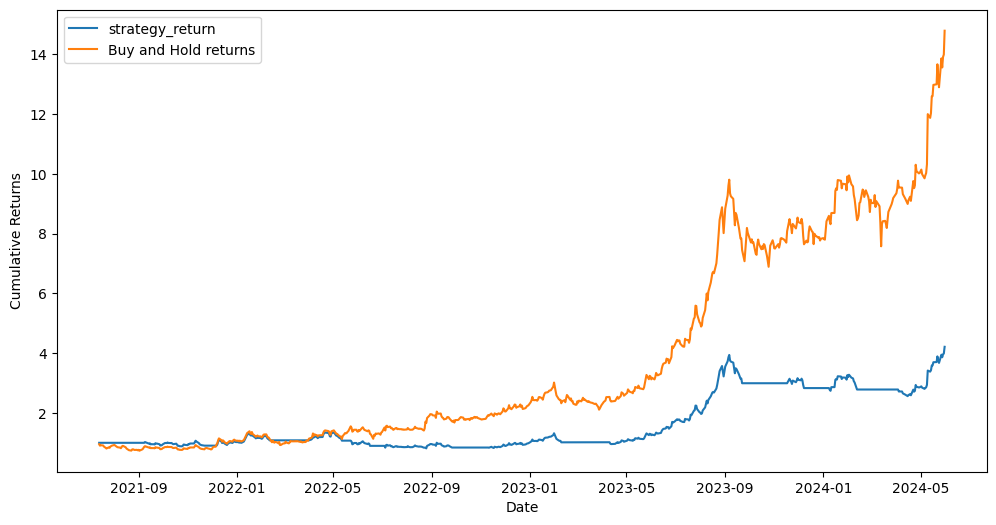

In [88]:
# Support and Resistance
dfb['resistance'] = dfb['high'].rolling(15).max().shift(1)
dfb['support'] = dfb['low'].rolling(15).min().shift(1)
dfb.dropna(inplace=True)
# Signal
dfb['signal'] = np.where(dfb['close'] > dfb['resistance'], 1,
                 np.where(dfb['close'] < dfb['support'], 0, np.nan))
dfb['signal'] = dfb['signal'].ffill()
dfb['signal'] = dfb['signal'].fillna(0)

# Removing Lookahead Bias
dfb['position'] = dfb['signal'].shift(1)


dfb['returns'] = dfb['close'].pct_change()
dfb['strategy_return'] = dfb['returns'] * dfb['position']
dfb['buy_and_hold_returns'] = 1 + dfb['returns']
dfb['strategy_return'] = 1 + dfb['strategy_return']

# Return Comparison
print("Buy and Hold", dfb['buy_and_hold_returns'].cumprod().iloc[-1])
print("Breakout_Strategy Returns", dfb['strategy_return'].cumprod().iloc[-1])

#Plotting
plt.figure(figsize=(12,6))
plt.plot(dfb['strategy_return'].cumprod(), label='strategy_return')
plt.plot(dfb['buy_and_hold_returns'].cumprod(), label='Buy and Hold returns')

plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.show()

# Volatility Based Regime Detection

In [91]:
df1.drop(columns=['high','low'], inplace=True)

KeyError: "['high', 'low'] not found in axis"

Buy & Hold Returns =  1.2368925730075775
Strategy Returns =  0.9606852409213583


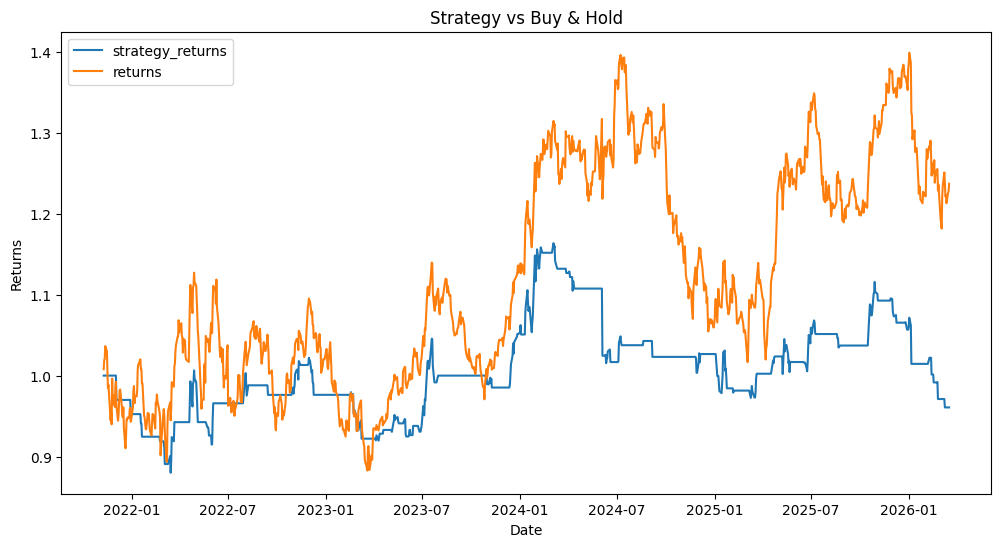

In [94]:
# Returns
df1['returns'] = df1['close'].pct_change()

#volatility
df1['short_volatility'] = df1['returns'].rolling(10).std()
df1['long_volatility'] = df1['returns'].rolling(20).std()
df1['volatility'] = np.where(df1['short_volatility'] > df1['long_volatility'],1,0)

#Trend
df1['ma'] = df1['close'].rolling(21).mean()
df1['trend'] = np.where(df1['close'] > df1['ma'], 1, 0)
#Trigger
df1['trigger'] = df1['volatility'] * df1['trend']
df1['trigger'] = df1['trigger'].shift(1)
df1.dropna(inplace=True)
# Strategy Retruns
df1['strategy_returns'] = df1['returns'] * df1['trigger']

#convert to compounding
df1['strategy_returns'] =  1 + df1['strategy_returns']
df1['returns'] = 1 + df1['returns']

#Performance
print("Buy & Hold Returns = ", df1['returns'].cumprod().iloc[-1])
print("Strategy Returns = ", df1['strategy_returns'].cumprod().iloc[-1])

# Plotting
plt.figure(figsize=(12,6))
plt.plot(df1['strategy_returns'].cumprod(), label='strategy_returns')
plt.plot(df1['returns'].cumprod(), label='returns')
plt.title('Strategy vs Buy & Hold')
plt.ylabel('Returns')
plt.xlabel('Date')
plt.legend()
plt.show()